In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Set parameters
n = 10**6  # Number of samples
c = np.sqrt(2 * np.exp(1) / np.pi)  # Max(f/g)
deltax = 0.1  # Grid spacing
xmax = 4  # Grid bound
x = np.arange(-xmax, xmax, deltax)  # Grid

# Sample the standard Laplace (double-sided exponential) distribution
U1 = np.random.rand(n)
L = np.log(2 * U1) * (U1 < 0.5) - np.log(2 * (1 - U1)) * (U1 >= 0.5)

In [3]:
# Sample the normal distribution using the acceptance-rejection method
g = 0.5 * np.exp(-np.abs(L))
f = (1 / np.sqrt(2 * np.pi)) * np.exp(-L**2 / 2)
U2 = np.random.rand(n)
N = L[U2 * c * g <= f]

In [4]:
acceptance_ratio = len(N) / n
print(f"Acceptance ratio: {acceptance_ratio}")


Acceptance ratio: 0.759988


In [5]:
# Numerical check
print(f"Numerical max(f/g): {np.max(f / g)}")
print(f"Analytical c value: {c}")

Numerical max(f/g): 1.3154892469588997
Analytical c value: 1.315489246958914


Text(0.5, 1.0, 'Standard normal distribution using the accept-reject algorithm')

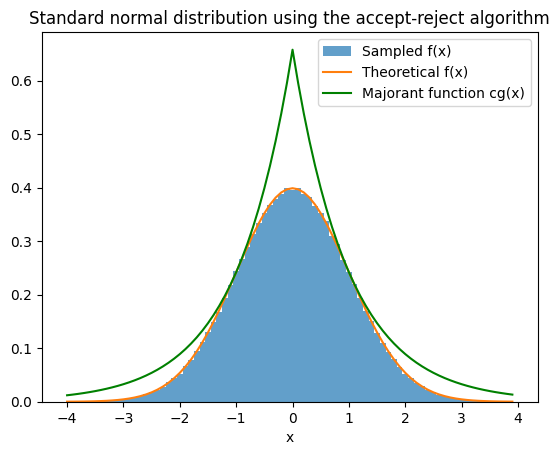

In [6]:
# Plot the results
plt.figure(1)
x2 = np.concatenate([x - deltax / 2, [x[-1] + deltax / 2]])  # Bin edges
plt.hist(N, bins=x2, density=True, alpha=0.7, label='Sampled f(x)')
fx = (1 / np.sqrt(2 * np.pi)) * np.exp(-x**2 / 2)  # Normal pdf
gx = 0.5 * np.exp(-np.abs(x))  # Laplace pdf
plt.plot(x, fx, label='Theoretical f(x)')
plt.plot(x, c * gx, 'g', label='Majorant function cg(x)')
plt.xlabel('x')
plt.legend()
plt.title('Standard normal distribution using the accept-reject algorithm')

Text(0.5, 1.0, 'x^2-2x+1 = 0 where f/g = max = c')

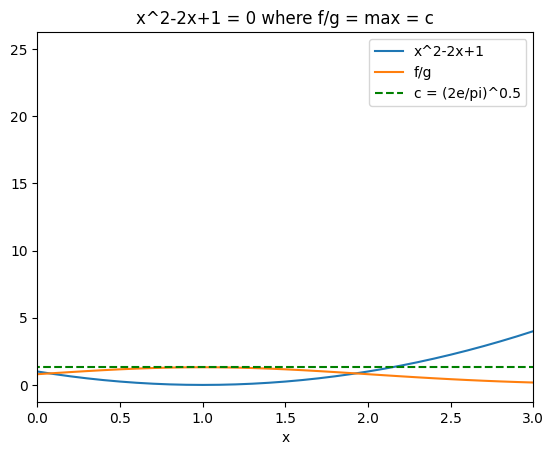

In [8]:

# Plot the second figure
plt.figure(2)
plt.plot(x, x**2 - 2*x + 1, label='x^2-2x+1')
plt.plot(x, fx / gx, label='f/g')
plt.plot(x, c * np.ones_like(x), '--g', label=f'c = (2e/pi)^{1/2}')
plt.xlim([0, 3])
plt.xlabel('x')
plt.legend()
plt.title('x^2-2x+1 = 0 where f/g = max = c')

